# Customer Segmentation via PCA — UK Online Retail

## Objective
Reduce dimensionality of customer behavioral variables using Principal Component Analysis (PCA),
then apply K-Means clustering to segment customers into actionable groups for a UK-based online retailer.

## Dataset
UCI Online Retail Dataset — transaction-level data from a UK-based online retailer (Dec 2010–Dec 2011).
Scoped to UK-only customers (~90% of transactions) to maintain behavioral coherence and avoid sparse
categorical noise from low-volume countries.

## Approach
1. Data cleaning (nulls, cancellations, duplicates)
2. RFM + behavioral feature engineering
3. Exploratory analysis to justify PCA (correlation, skewness)
4. Preprocessing (log transform, encoding, scaling)
5. PCA (component selection, loadings interpretation)
6. K-Means clustering — compared with vs. without PCA
7. Cluster profiling and business interpretation


## Phase 1 — Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('online_retail.csv', parse_dates = ['InvoiceDate'])
df.shape

(541909, 8)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()
print('\n')
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB




InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
#Dropping rows with missing customerID

df = df.dropna(subset=['CustomerID'])
df.shape

(406829, 8)

In [6]:
#Fixing cusstomerID type, converting to int.

df['CustomerID'] = df['CustomerID'].astype(int)

In [7]:
# Checking for negative or zero values.

print('Negative Quantity rows:', (df['Quantity'] < 0).sum())
print('Negative UnitPrice rows:', (df['UnitPrice'] < 0).sum())
print('Zero UnitPrice rows:', (df['UnitPrice'] == 0).sum())

Negative Quantity rows: 8905
Negative UnitPrice rows: 0
Zero UnitPrice rows: 40


In [8]:
# Checking the negative quantities
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897,United Kingdom


In [9]:
""" It is found that all quantities with invoiceNo starting with 'C' is negative.
on futher investigation it meant cancellations or returns. Therefore, i am removing cancellations from dataframe"""

df['InvoiceNo'] = df['InvoiceNo'].astype(str) # Converting to string.
df['is_cancelled'] = df['InvoiceNo'].str.startswith('C') # Flagging InvoiceNo starting with 'C' as "is_cancelled"
print(df['is_cancelled'].value_counts()) # Counting is_cancelled.

is_cancelled
False    397924
True       8905
Name: count, dtype: int64


In [10]:
# Excluding cancellations to keep monetary values clean.

df = df[~df['is_cancelled']]
df.shape

(397924, 9)

In [11]:
# Removing zero or negative UnitPrice rows.

df = df[df['UnitPrice']  > 0]
df.shape

(397884, 9)

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


In [13]:
# Checking for duplicates before processing.

df.duplicated().sum()
df = df.drop_duplicates()
df.shape

(392692, 9)

In [14]:
# Filtering country to UK only. For cleaner PCA signalling as 90% is just U.K.

df['Country'].value_counts().head(10)

df = df[df['Country'] == 'United Kingdom']
df.shape

(349203, 9)

In [15]:
# Checking final customer count.

df['CustomerID'].nunique()

3920

In [16]:
# Creating a TotalPrice column.

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,False,54.08


In [17]:
# sanity check for the cleaned data.

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,349203.000000,349203,349203.000000,349203.000000,349203.000000
mean,12.145672,2011-07-11 03:25:52.818962176,2.972328,15548.384252,20.861862
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:40:00,1.250000,14191.000000,4.200000
50%,4.000000,2011-07-31 13:37:00,1.950000,15518.000000,10.200000
75%,12.000000,2011-10-23 11:07:30,3.750000,16931.000000,17.850000
max,80995.000000,2011-12-09 12:49:00,8142.750000,18287.000000,168469.600000
std,190.628818,NaN,17.990908,1594.384044,328.417275


In [18]:
# Saving the cleaned dataset.

df.to_csv('online_retail_cleaned.csv', index = False)

## Phase 2 — RFM & Behavioral Feature Engineering

Why PCA?
Before applying PCA, we check whether the behavioral features are actually correlated enough
to justify dimensionality reduction. If features were independent, PCA would have nothing to compress.

In [19]:
df = pd.read_csv('online_retail_cleaned.csv', parse_dates = ['InvoiceDate'])
df.shape

(349203, 10)

In [20]:
# Setting reference date for "Recency"
# Recency needs a fixed "today" — use one day after the last transaction in the dataset

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:49:00')

In [21]:
# Core RFM(Recency, Frequency, Monetary)
# Recency Calculation
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days
recency_df = recency_df[['CustomerID', 'Recency']]
recency_df.head()

,CustomerID,Recency
0,12346,326
1,12747,2
2,12748,1
3,12749,4
4,12820,3


In [22]:
# Frequency Calculation.

frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346,1
1,12747,11
2,12748,209
3,12749,5
4,12820,4


In [23]:
# Monetary Claculation

monetary_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346,77183.60
1,12747,4196.01
2,12748,33053.19
3,12749,4090.88
4,12820,942.34


In [24]:
# Merging RFM into one table.

rfm = recency_df.merge(frequency_df, on='CustomerID').merge(monetary_df, on='CustomerID')
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,209,33053.19
3,12749,4,5,4090.88
4,12820,3,4,942.34


In [25]:
# Behavioral: average basket size (items per invoice)

basket_size = df.groupby(['CustomerID', 'InvoiceNo'])['Quantity'].sum().reset_index()
avg_basket = basket_size.groupby('CustomerID')['Quantity'].mean().reset_index()
avg_basket.columns = ['CustomerID', 'AvgBasketSize']
avg_basket.head()

,CustomerID,AvgBasketSize
0,12346,74215.000000
1,12747,115.909091
2,12748,120.990431
3,12749,294.200000
4,12820,180.500000


In [26]:
# Behavioral: average order value

order_value = df.groupby(['CustomerID', 'InvoiceNo'])['TotalPrice'].sum().reset_index()
avg_order_value = order_value.groupby('CustomerID')['TotalPrice'].mean().reset_index()
avg_order_value.columns = ['CustomerID', 'AvgOrderValue']
avg_order_value.head()

,CustomerID,AvgOrderValue
0,12346,77183.600000
1,12747,381.455455
2,12748,158.149234
3,12749,818.176000
4,12820,235.585000


In [27]:
# Behavioral: product variety (distinct items purchased)

product_variety = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
product_variety.columns = ['CustomerID', 'ProductVariety']
product_variety.head()

,CustomerID,ProductVariety
0,12346,1
1,12747,42
2,12748,1768
3,12749,160
4,12820,55


In [28]:
# Behavioral: tenure (days since first purchase)

first_purchase = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase['Tenure'] = (reference_date - first_purchase['InvoiceDate']).dt.days
tenure_df = first_purchase[['CustomerID', 'Tenure']]
tenure_df.head()

,CustomerID,Tenure
0,12346,326
1,12747,369
2,12748,374
3,12749,213
4,12820,327


In [29]:
# Behavioral: favorite shopping day of week

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
fav_day = df.groupby('CustomerID')['DayOfWeek'].agg(lambda x: x.mode()[0]).reset_index()
fav_day.columns = ['CustomerID', 'FavDayOfWeek']
fav_day.head()

,CustomerID,FavDayOfWeek
0,12346,Tuesday
1,12747,Tuesday
2,12748,Wednesday
3,12749,Monday
4,12820,Monday


In [30]:
# Behavioral: purchase frequency trend (early vs late half)

midpoint = df['InvoiceDate'].min() + (df['InvoiceDate'].max() - df['InvoiceDate'].min()) / 2

early = df[df['InvoiceDate'] <= midpoint].groupby('CustomerID')['InvoiceNo'].nunique()
late = df[df['InvoiceDate'] > midpoint].groupby('CustomerID')['InvoiceNo'].nunique()

trend_df = pd.DataFrame({'EarlyOrders': early, 'LateOrders': late}).fillna(0).reset_index()
trend_df['OrderTrend'] = trend_df['LateOrders'] - trend_df['EarlyOrders']
trend_df = trend_df[['CustomerID', 'OrderTrend']]
trend_df.head()

,CustomerID,OrderTrend
0,12346,-1.0
1,12747,-1.0
2,12748,37.0
3,12749,3.0
4,12820,2.0


In [31]:
# Merge everything into one customer feature table

customer_df = rfm.merge(avg_basket, on='CustomerID') \
                  .merge(avg_order_value, on='CustomerID') \
                  .merge(product_variety, on='CustomerID') \
                  .merge(tenure_df, on='CustomerID') \
                  .merge(fav_day, on='CustomerID') \
                  .merge(trend_df, on='CustomerID')

customer_df.shape

(3920, 10)

In [32]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend
0,12346,326,1,77183.60,74215.000000,77183.600000,1,326,Tuesday,-1.0
1,12747,2,11,4196.01,115.909091,381.455455,42,369,Tuesday,-1.0
2,12748,1,209,33053.19,120.990431,158.149234,1768,374,Wednesday,37.0
3,12749,4,5,4090.88,294.200000,818.176000,160,213,Monday,3.0
4,12820,3,4,942.34,180.500000,235.585000,55,327,Monday,2.0


In [33]:
customer_df.describe()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,OrderTrend
count,3920.000000,3920.000000,3920.000000,3920.000000,3920.000000,3920.000000,3920.000000,3920.000000,3920.000000
mean,15562.059694,92.208418,4.246429,1858.424654,242.105368,391.683084,60.726531,223.553571,0.743367
std,1576.594671,99.533854,7.199202,7478.631256,1373.096462,1869.923744,81.670816,118.070706,2.576704
min,12346.000000,1.000000,1.000000,3.750000,1.000000,3.450000,1.000000,1.000000,-34.000000
25%,14208.750000,18.000000,1.000000,298.185000,90.000000,173.649687,15.000000,112.000000,-1.000000
50%,15569.500000,51.000000,2.000000,644.975000,154.928571,279.565500,35.000000,249.000000,1.000000
75%,16913.250000,143.000000,5.000000,1571.285000,259.233333,408.147500,77.000000,327.000000,2.000000
max,18287.000000,374.000000,209.000000,259657.300000,74215.000000,84236.250000,1768.000000,374.000000,37.000000


In [34]:
customer_df.isna().sum()

CustomerID        0
Recency           0
Frequency         0
Monetary          0
AvgBasketSize     0
AvgOrderValue     0
ProductVariety    0
Tenure            0
FavDayOfWeek      0
OrderTrend        0
dtype: int64

In [35]:
customer_df.to_csv('customer_features.csv', index=False)

## Phase 3 & 4 — Exploratory Analysis, Transformation & Scaling

In [36]:
customer_df = pd.read_csv('customer_features.csv')
customer_df.shape

(3920, 10)

In [37]:
# CustomerID isn't a behavioral feature, FavDayOfWeek is categorical - set aside for now
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'AvgBasketSize',
                 'AvgOrderValue', 'ProductVariety', 'Tenure', 'OrderTrend']

numeric_df = customer_df[numeric_cols]
numeric_df.head()

,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,OrderTrend
0,326,1,77183.60,74215.000000,77183.600000,1,326,-1.0
1,2,11,4196.01,115.909091,381.455455,42,369,-1.0
2,1,209,33053.19,120.990431,158.149234,1768,374,37.0
3,4,5,4090.88,294.200000,818.176000,160,213,3.0
4,3,4,942.34,180.500000,235.585000,55,327,2.0


In [38]:
# checking the skewness of each feature

numeric_df.skew().sort_values(ascending=False)

AvgBasketSize     46.438370
AvgOrderValue     40.920412
Monetary          20.217581
Frequency         10.751932
ProductVariety     6.015345
OrderTrend         1.433594
Recency            1.245264
Tenure            -0.368672
dtype: float64

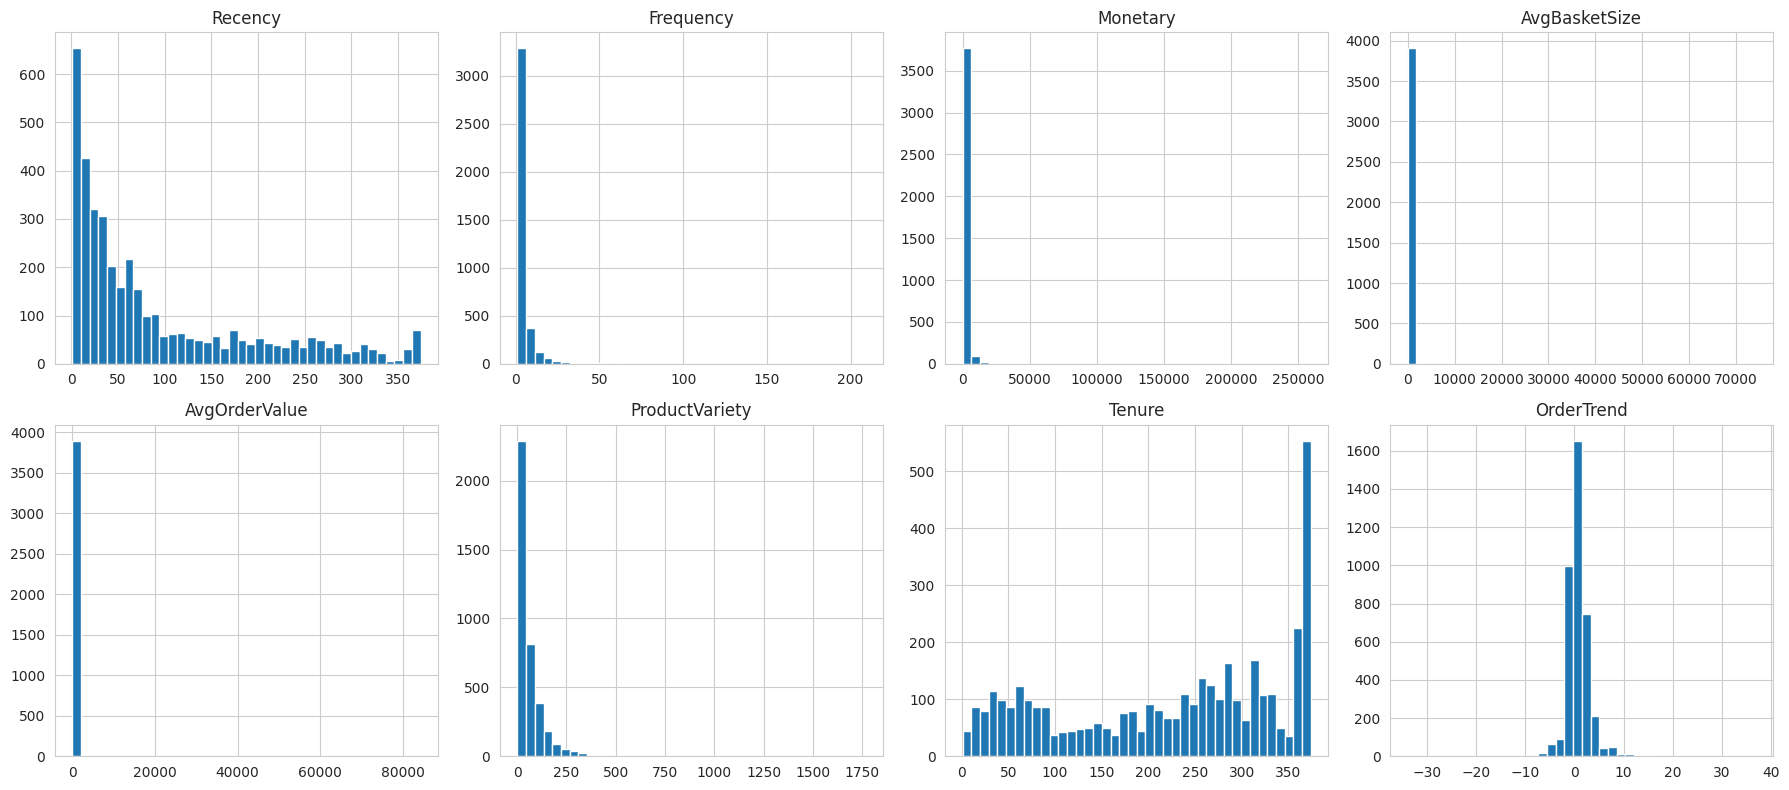

In [39]:
# Visualizing the results.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(numeric_df[col], bins=40)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

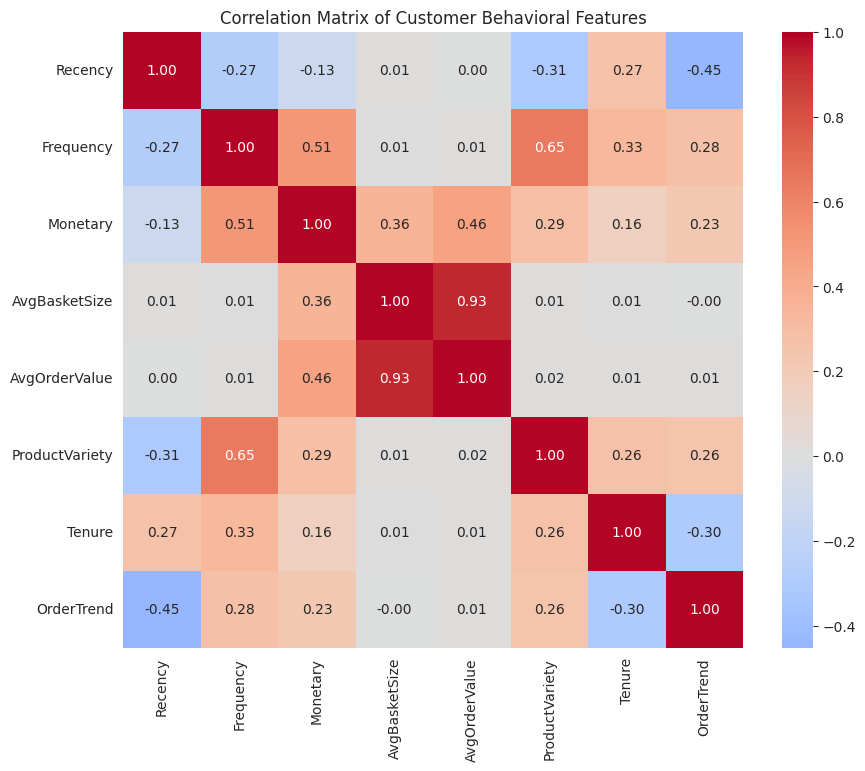

In [40]:
# corelation heatmap.

plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Customer Behavioral Features')
plt.show()

In [41]:
# Printinng the strongest correlations explicitly.

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
corr_pairs.sort_values(ascending=False, key=abs)

AvgBasketSize   AvgOrderValue     0.932094
Frequency       ProductVariety    0.645963
                Monetary          0.507724
Monetary        AvgOrderValue     0.458081
Recency         OrderTrend       -0.451125
Monetary        AvgBasketSize     0.357442
Frequency       Tenure            0.329198
Recency         ProductVariety   -0.309951
Tenure          OrderTrend       -0.302715
Monetary        ProductVariety    0.285211
Frequency       OrderTrend        0.276264
Recency         Frequency        -0.273880
                Tenure            0.268326
ProductVariety  Tenure            0.264020
                OrderTrend        0.257150
Monetary        OrderTrend        0.227241
                Tenure            0.156816
Recency         Monetary         -0.129021
AvgOrderValue   ProductVariety    0.019161
Frequency       AvgOrderValue     0.014502
AvgBasketSize   ProductVariety    0.011403
Recency         AvgBasketSize     0.010185
AvgOrderValue   Tenure            0.010054
           

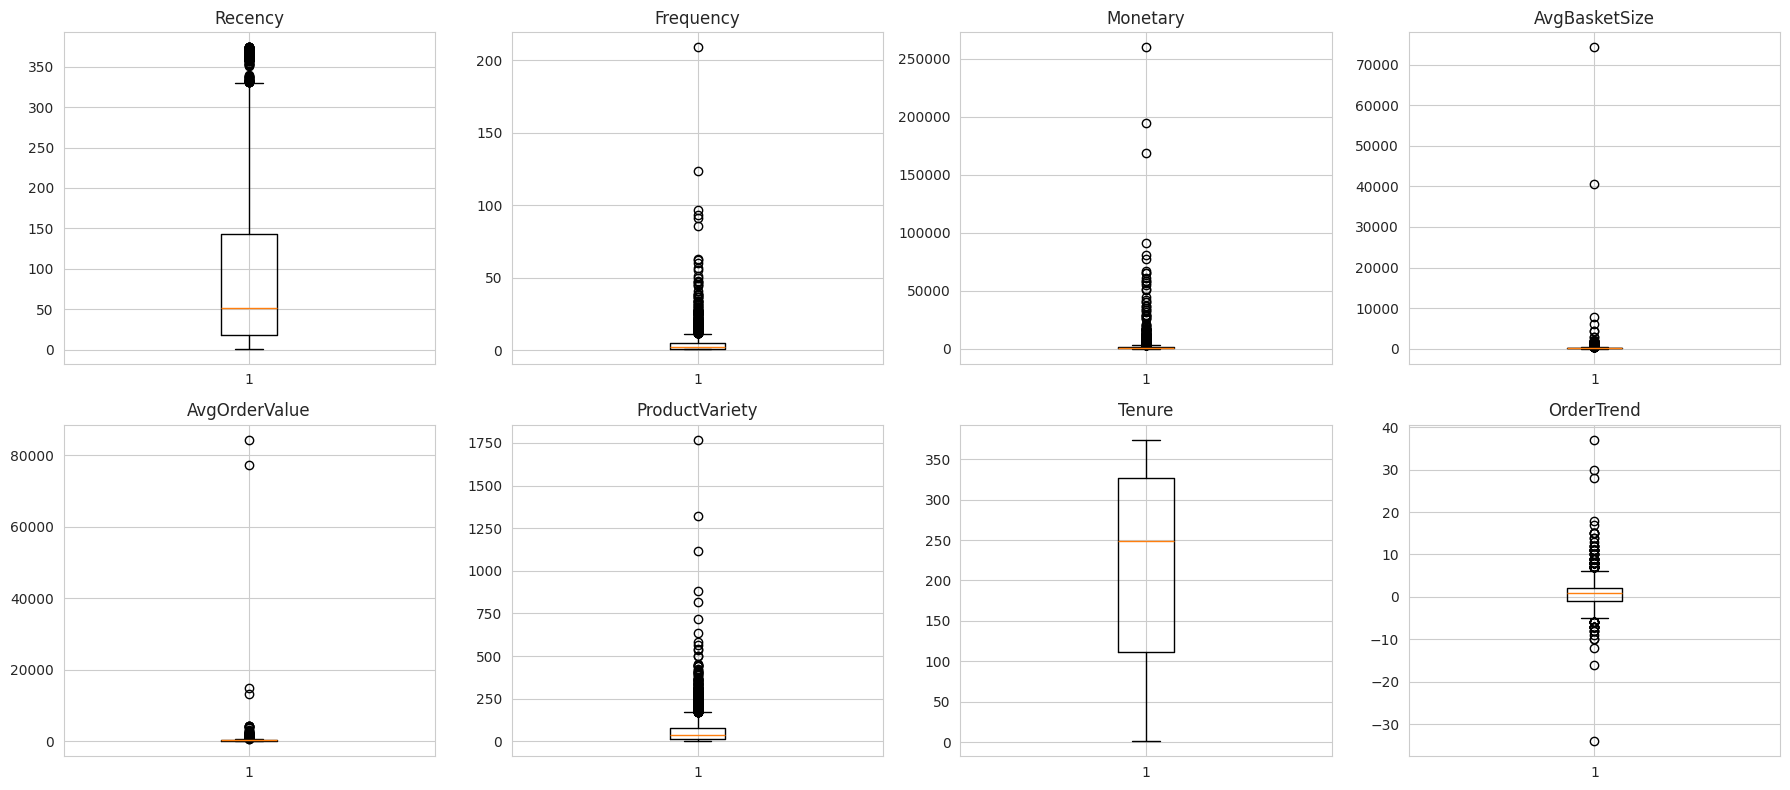

In [42]:
# Check for outliers via boxplots.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(numeric_df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [43]:
# Big Buyers, likely Wholesalers.

customer_df.sort_values('Monetary', ascending=False).head(15)

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend
3783,18102,1,60,259657.30,1068.733333,4327.621667,150,367,Monday,30.0
3314,17450,8,46,194390.79,1521.152174,4225.886739,124,368,Tuesday,18.0
2598,16446,1,2,168472.50,40498.500000,84236.250000,3,206,Wednesday,0.0
3356,17511,3,31,91062.38,2082.225806,2937.496129,453,374,Wednesday,1.0
2294,16029,39,63,80850.84,636.634921,1283.346667,44,374,Wednesday,5.0
0,12346,326,1,77183.60,74215.000000,77183.600000,1,326,Tuesday,-1.0
2766,16684,4,28,66653.56,1794.821429,2380.484286,119,358,Wednesday,2.0
902,14096,4,17,65164.79,961.882353,3833.222941,1119,102,Monday,17.0
620,13694,4,50,65039.62,1266.240000,1300.792400,366,374,Thursday,-2.0
1771,15311,1,91,60632.75,419.197802,666.293956,567,374,Tuesday,3.0


In [44]:
# Log Transforming Skewed features
# log1p handles zero values safely (log(1+x) instead of log(x))
skewed_cols = ['Frequency', 'Monetary', 'AvgBasketSize', 'AvgOrderValue', 'ProductVariety']

for col in skewed_cols:
    customer_df[col + '_log'] = np.log1p(customer_df[col])

customer_df[[c + '_log' for c in skewed_cols]].head()

,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log
0,0.693147,11.253955,11.214735,11.253955,0.693147
1,2.484907,8.342128,4.761397,5.946612,3.761200
2,5.347108,10.405904,4.803943,5.069842,7.478170
3,1.791759,8.316760,5.687653,6.708299,5.081404
4,1.609438,6.849427,5.201256,5.466308,4.025352


In [45]:
log_cols = [c + '_log' for c in skewed_cols]
customer_df[log_cols].skew().sort_values(ascending=False)

Frequency_log         1.182249
Monetary_log          0.373135
AvgOrderValue_log     0.133491
ProductVariety_log   -0.254720
AvgBasketSize_log    -0.424445
dtype: float64

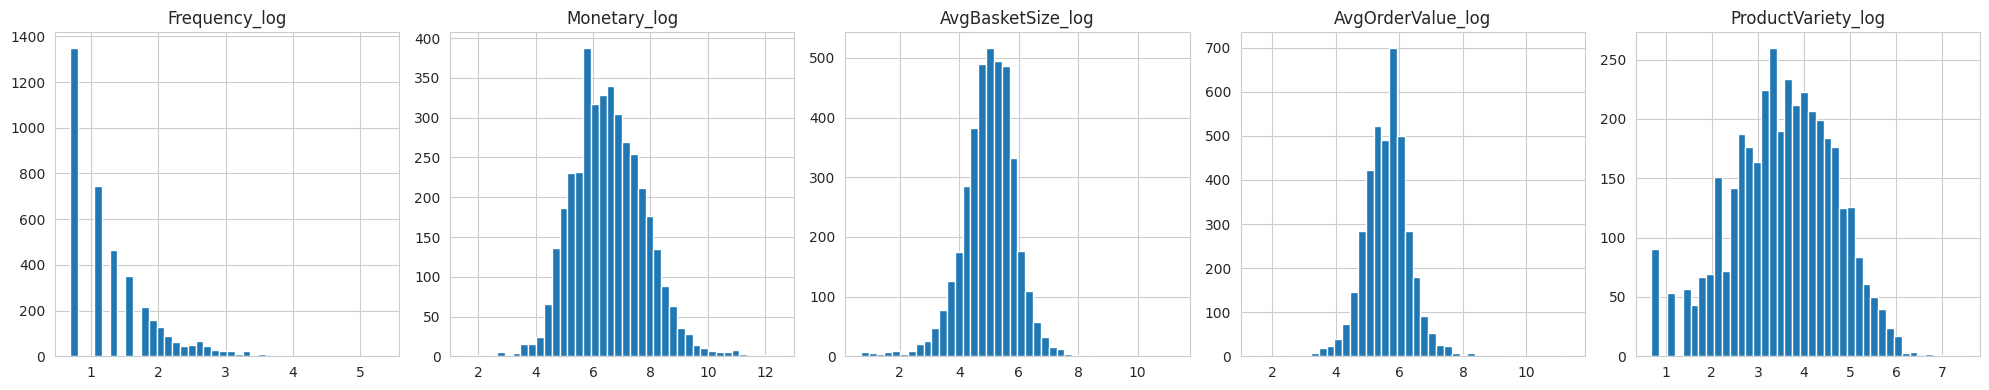

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(log_cols):
    axes[i].hist(customer_df[col], bins=40)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [47]:
# checking for outliers

customer_df.sort_values('Monetary', ascending=False).head(15)

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log
3783,18102,1,60,259657.30,1068.733333,4327.621667,150,367,Monday,30.0,4.110874,12.467122,6.975165,8.373004,5.017280
3314,17450,8,46,194390.79,1521.152174,4225.886739,124,368,Tuesday,18.0,3.850148,12.177631,7.327881,8.349221,4.828314
2598,16446,1,2,168472.50,40498.500000,84236.250000,3,206,Wednesday,0.0,1.098612,12.034534,10.609045,11.341393,1.386294
3356,17511,3,31,91062.38,2082.225806,2937.496129,453,374,Wednesday,1.0,3.465736,11.419311,7.641673,7.985653,6.118097
2294,16029,39,63,80850.84,636.634921,1283.346667,44,374,Wednesday,5.0,4.158883,11.300374,6.457766,7.158005,3.806662
0,12346,326,1,77183.60,74215.000000,77183.600000,1,326,Tuesday,-1.0,0.693147,11.253955,11.214735,11.253955,0.693147
2766,16684,4,28,66653.56,1794.821429,2380.484286,119,358,Wednesday,2.0,3.367296,11.107279,7.493218,7.775479,4.787492
902,14096,4,17,65164.79,961.882353,3833.222941,1119,102,Monday,17.0,2.890372,11.084690,6.869931,8.251722,7.021084
620,13694,4,50,65039.62,1266.240000,1300.792400,366,374,Thursday,-2.0,3.931826,11.082767,7.144597,7.171497,5.905362
1771,15311,1,91,60632.75,419.197802,666.293956,567,374,Tuesday,3.0,4.521789,11.012607,6.040726,6.503231,6.342121


In [48]:
# Checking for skewness of Recency, Tenure

customer_df[['Recency', 'Tenure', 'OrderTrend']].skew()

Recency       1.245264
Tenure       -0.368672
OrderTrend    1.433594
dtype: float64

In [49]:
# One-hot encoding FavDayOfWeek

day_dummies = pd.get_dummies(customer_df['FavDayOfWeek'], prefix='Day')
day_dummies = day_dummies.astype(int)
day_dummies.head()

,Day_Friday,Day_Monday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,0,1
3,0,1,0,0,0,0
4,0,1,0,0,0,0


In [50]:
# Build final feature set for PCA

final_features = pd.concat([
    customer_df[['Recency', 'Tenure', 'OrderTrend']],
    customer_df[log_cols],
    day_dummies
], axis=1)

final_features.head()

,Recency,Tenure,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log,Day_Friday,Day_Monday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,326,326,-1.0,0.693147,11.253955,11.214735,11.253955,0.693147,0,0,0,0,1,0
1,2,369,-1.0,2.484907,8.342128,4.761397,5.946612,3.761200,0,0,0,0,1,0
2,1,374,37.0,5.347108,10.405904,4.803943,5.069842,7.478170,0,0,0,0,0,1
3,4,213,3.0,1.791759,8.316760,5.687653,6.708299,5.081404,0,1,0,0,0,0
4,3,327,2.0,1.609438,6.849427,5.201256,5.466308,4.025352,0,1,0,0,0,0


In [51]:
# Keeping CustomerID separately (for later profiling, not for PCA itself)

customer_ids = customer_df['CustomerID']
final_features.shape

(3920, 14)

In [52]:
# Scale everything with StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(final_features)

scaled_df = pd.DataFrame(scaled_array, columns=final_features.columns)
scaled_df.head()

,Recency,Tenure,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log,Day_Friday,Day_Monday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2.349165,0.867781,-0.676674,-0.957491,3.788077,6.961183,7.869017,-2.490874,-0.408248,-0.430956,-0.407823,-0.533295,2.276613,-0.460159
1,-0.906425,1.232016,-0.676674,1.668959,1.447841,-0.267644,0.486085,0.198123,-0.408248,-0.430956,-0.407823,-0.533295,2.276613,-0.460159
2,-0.916473,1.274369,14.072728,5.864515,3.106498,-0.219985,-0.733571,3.455863,-0.408248,-0.430956,-0.407823,-0.533295,-0.439249,2.173161
3,-0.886328,-0.089395,0.875894,0.652910,1.427453,0.769920,1.545651,1.355217,-0.408248,2.320423,-0.407823,-0.533295,-0.439249,-0.460159
4,-0.896376,0.876251,0.487752,0.385654,0.248157,0.225072,-0.182056,0.429639,-0.408248,2.320423,-0.407823,-0.533295,-0.439249,-0.460159


In [53]:
# Sanity checking the standard scalar.

scaled_df.describe().loc[['mean', 'std']]

,Recency,Tenure,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log,Day_Friday,Day_Monday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
mean,-4.984675e-18,1.033187e-16,7.250436e-18,2.329203e-16,3.552714e-16,-5.184062e-16,5.256566e-16,-4.685594e-16,3.081435e-17,2.718914e-17,2.175131e-17,5.075305e-17,2.900174e-17,-1.450087e-17
std,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00


In [54]:
customer_df.to_csv('customer_features_transformed.csv', index=False)

In [55]:
scaled_df.to_csv('scaled_features.csv', index=False)
customer_ids.to_csv('customer_ids.csv', index=False)

In [56]:
customer_df.sort_values('Monetary', ascending=False).head(15)

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log
3783,18102,1,60,259657.30,1068.733333,4327.621667,150,367,Monday,30.0,4.110874,12.467122,6.975165,8.373004,5.017280
3314,17450,8,46,194390.79,1521.152174,4225.886739,124,368,Tuesday,18.0,3.850148,12.177631,7.327881,8.349221,4.828314
2598,16446,1,2,168472.50,40498.500000,84236.250000,3,206,Wednesday,0.0,1.098612,12.034534,10.609045,11.341393,1.386294
3356,17511,3,31,91062.38,2082.225806,2937.496129,453,374,Wednesday,1.0,3.465736,11.419311,7.641673,7.985653,6.118097
2294,16029,39,63,80850.84,636.634921,1283.346667,44,374,Wednesday,5.0,4.158883,11.300374,6.457766,7.158005,3.806662
0,12346,326,1,77183.60,74215.000000,77183.600000,1,326,Tuesday,-1.0,0.693147,11.253955,11.214735,11.253955,0.693147
2766,16684,4,28,66653.56,1794.821429,2380.484286,119,358,Wednesday,2.0,3.367296,11.107279,7.493218,7.775479,4.787492
902,14096,4,17,65164.79,961.882353,3833.222941,1119,102,Monday,17.0,2.890372,11.084690,6.869931,8.251722,7.021084
620,13694,4,50,65039.62,1266.240000,1300.792400,366,374,Thursday,-2.0,3.931826,11.082767,7.144597,7.171497,5.905362
1771,15311,1,91,60632.75,419.197802,666.293956,567,374,Tuesday,3.0,4.521789,11.012607,6.040726,6.503231,6.342121


Note: Excluding Day-of-Week from PCA
An initial PCA run included one-hot encoded `FavDayOfWeek`. This resulted in components PC4–PC7
being driven almost entirely by day-of-week dummy variables with minimal mixing with behavioral
features — indicating the categorical encoding was consuming dimensionality without adding
meaningful segmentation signal. We re-ran PCA on the 7 continuous behavioral features only,
which reduced the components needed for 90% variance from ~9 down to 4, with every component
cleanly interpretable in behavioral terms.

## Phase 5 — PCA (Component Selection & Loadings)

In [57]:
customer_df = pd.read_csv('customer_features_transformed.csv')
scaled_df = pd.read_csv('scaled_features.csv')
customer_ids = pd.read_csv('customer_ids.csv')

skewed_cols = ['Frequency', 'Monetary', 'AvgBasketSize', 'AvgOrderValue', 'ProductVariety']
log_cols = [c + '_log' for c in skewed_cols]

scaled_df.shape

(3920, 14)

In [58]:
# Fitting PCA with all the components

from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(scaled_df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [59]:
#Explaining variance per component

explained_var = pca_full.explained_variance_ratio_
for i, var in enumerate(explained_var, 1):
    print(f'PC{i}: {var:.4f} ({var*100:.2f}%)')

PC1: 0.2559 (25.59%)
PC2: 0.1186 (11.86%)
PC3: 0.1034 (10.34%)
PC4: 0.0897 (8.97%)
PC5: 0.0861 (8.61%)
PC6: 0.0844 (8.44%)
PC7: 0.0837 (8.37%)
PC8: 0.0830 (8.30%)
PC9: 0.0398 (3.98%)
PC10: 0.0284 (2.84%)
PC11: 0.0159 (1.59%)
PC12: 0.0109 (1.09%)
PC13: 0.0002 (0.02%)
PC14: 0.0000 (0.00%)


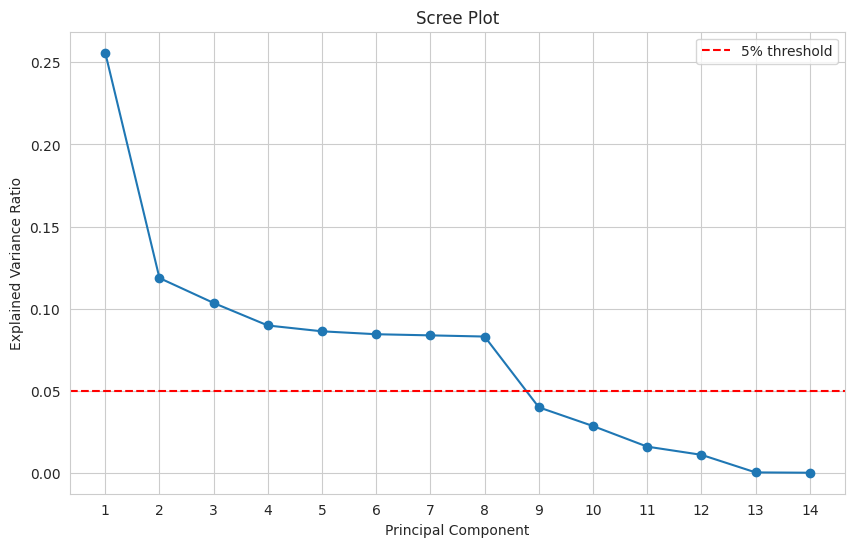

In [60]:
# Scree Plotting

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_var) + 1))
plt.axhline(y=0.05, color='r', linestyle='--', label='5% threshold')
plt.legend()
plt.show()

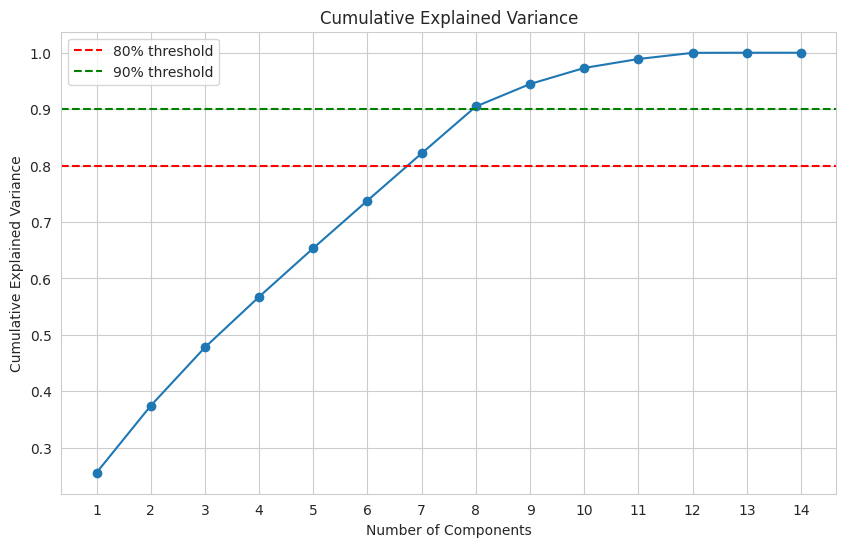

In [61]:
# Cumulative variance

cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% threshold')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% threshold')
plt.xticks(range(1, len(cumulative_var) + 1))
plt.legend()
plt.grid(True)
plt.show()

In [62]:
for i, cum in enumerate(cumulative_var, 1):
    print(f'{i} components: {cum*100:.2f}% cumulative variance')

1 components: 25.59% cumulative variance
2 components: 37.45% cumulative variance
3 components: 47.79% cumulative variance
4 components: 56.76% cumulative variance
5 components: 65.37% cumulative variance
6 components: 73.81% cumulative variance
7 components: 82.18% cumulative variance
8 components: 90.47% cumulative variance
9 components: 94.46% cumulative variance
10 components: 97.30% cumulative variance
11 components: 98.89% cumulative variance
12 components: 99.98% cumulative variance
13 components: 100.00% cumulative variance
14 components: 100.00% cumulative variance


In [63]:
n_components = 8  # Components above 80%
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,5.135106,0.996580,9.689550,-0.098117,-1.438824,-1.133771,-0.157723,1.416697
1,1.958976,1.318296,-0.554184,-0.766316,-1.612703,-1.289983,-0.980643,-0.982169
2,8.089659,-4.872036,-7.125478,-0.657094,3.122471,-1.523413,-0.887171,-2.531063
3,2.778228,-1.011387,0.532192,-0.126933,-0.240347,2.125040,-0.902934,-0.590733
4,0.950304,-0.282935,-0.497985,-0.312104,-0.268486,2.173663,-1.023451,-0.890106


In [64]:
customer_df.columns.tolist()

['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'AvgBasketSize',
 'AvgOrderValue',
 'ProductVariety',
 'Tenure',
 'FavDayOfWeek',
 'OrderTrend',
 'Frequency_log',
 'Monetary_log',
 'AvgBasketSize_log',
 'AvgOrderValue_log',
 'ProductVariety_log']

In [65]:
# Rebuilding final feature set WITHOUT Day_* columns
behavioral_cols = ['Recency', 'Tenure', 'OrderTrend'] + log_cols
final_features_v2 = customer_df[behavioral_cols]
final_features_v2.head()

,Recency,Tenure,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log
0,326,326,-1.0,0.693147,11.253955,11.214735,11.253955,0.693147
1,2,369,-1.0,2.484907,8.342128,4.761397,5.946612,3.761200
2,1,374,37.0,5.347108,10.405904,4.803943,5.069842,7.478170
3,4,213,3.0,1.791759,8.316760,5.687653,6.708299,5.081404
4,3,327,2.0,1.609438,6.849427,5.201256,5.466308,4.025352


In [66]:
# Re-scaling and re-run PCA on this trimmed behavioral-only set
from sklearn.preprocessing import StandardScaler

scaler_v2 = StandardScaler()
scaled_v2 = scaler_v2.fit_transform(final_features_v2)
scaled_df_v2 = pd.DataFrame(scaled_v2, columns=final_features_v2.columns)

pca_v2_full = PCA()
pca_v2_full.fit(scaled_df_v2)

cumulative_var_v2 = np.cumsum(pca_v2_full.explained_variance_ratio_)
for i, cum in enumerate(cumulative_var_v2, 1):
    print(f'{i} components: {cum*100:.2f}% cumulative variance')

1 components: 44.74% cumulative variance
2 components: 65.25% cumulative variance
3 components: 83.05% cumulative variance
4 components: 90.11% cumulative variance
5 components: 95.26% cumulative variance
6 components: 98.05% cumulative variance
7 components: 99.97% cumulative variance
8 components: 100.00% cumulative variance


In [67]:
print(f'Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Total variance retained: 90.47%


In [68]:
# Building the loadings table.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=scaled_df.columns
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Recency,-0.292156,0.428764,0.308968,-0.048465,-0.000757,0.059489,0.032601,0.095585
Tenure,0.158700,0.667296,-0.143514,-0.104193,-0.039202,0.094418,-0.004554,-0.058127
OrderTrend,0.175995,-0.510006,-0.242988,0.052816,0.091076,-0.086602,-0.024463,-0.113440
Frequency_log,0.409618,0.193186,-0.405941,-0.024509,0.010687,0.007044,-0.020633,-0.157155
Monetary_log,0.507701,0.115363,0.012587,0.005917,0.004086,0.012956,0.011840,-0.036574
AvgBasketSize_log,0.349874,-0.108997,0.519616,0.039751,0.003005,0.002412,0.049239,0.137874
AvgOrderValue_log,0.362683,-0.040606,0.535268,0.044008,0.000072,0.010768,0.043442,0.129296
ProductVariety_log,0.421743,0.055567,-0.142018,-0.036275,-0.058878,0.041583,0.016157,0.078805
Day_Friday,-0.022476,-0.033557,0.051580,-0.123033,-0.058052,0.031344,0.821854,-0.389823
Day_Monday,-0.005222,-0.122638,0.079366,-0.085204,-0.089659,0.783263,-0.361510,-0.244024


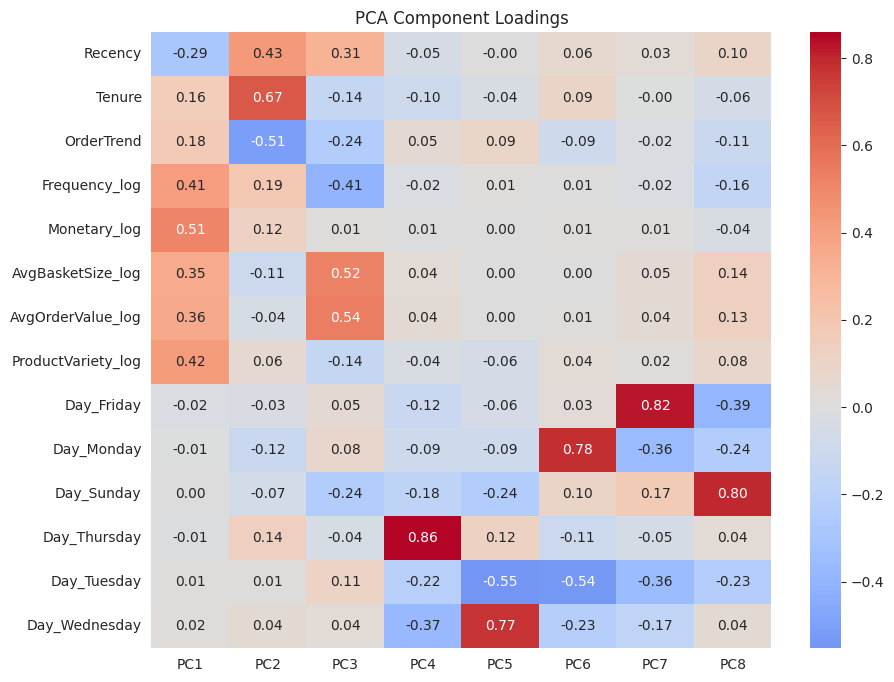

In [69]:
# Heatmap of the Loadings.

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA Component Loadings')
plt.show()

In [70]:
# Top contributing features per component.

for pc in loadings.columns:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(4)
    print(f'\n{pc} top contributors:')
    print(loadings.loc[top_features.index, pc])


PC1 top contributors:
Monetary_log          0.507701
ProductVariety_log    0.421743
Frequency_log         0.409618
AvgOrderValue_log     0.362683
Name: PC1, dtype: float64

PC2 top contributors:
Tenure           0.667296
OrderTrend      -0.510006
Recency          0.428764
Frequency_log    0.193186
Name: PC2, dtype: float64

PC3 top contributors:
AvgOrderValue_log    0.535268
AvgBasketSize_log    0.519616
Frequency_log       -0.405941
Recency              0.308968
Name: PC3, dtype: float64

PC4 top contributors:
Day_Thursday     0.859431
Day_Wednesday   -0.374925
Day_Tuesday     -0.215188
Day_Sunday      -0.175056
Name: PC4, dtype: float64

PC5 top contributors:
Day_Wednesday    0.771619
Day_Tuesday     -0.552947
Day_Sunday      -0.244957
Day_Thursday     0.118330
Name: PC5, dtype: float64

PC6 top contributors:
Day_Monday       0.783263
Day_Tuesday     -0.538830
Day_Wednesday   -0.226477
Day_Thursday    -0.110154
Name: PC6, dtype: float64

PC7 top contributors:
Day_Friday     0.821854

In [71]:
pca_df.to_csv('pca_features.csv', index=False)
loadings.to_csv('pca_loadings.csv')

In [72]:
# On finding that days just added more noise , we use cleaned version without them.

n_components_v2 = 4
pca_v2 = PCA(n_components=n_components_v2)
pca_result_v2 = pca_v2.fit_transform(scaled_df_v2)

pca_df_v2 = pd.DataFrame(pca_result_v2, columns=[f'PC{i+1}' for i in range(n_components_v2)])
print(f'Total variance retained: {pca_v2.explained_variance_ratio_.sum()*100:.2f}%')
pca_df_v2.head()

Total variance retained: 90.11%


,PC1,PC2,PC3,PC4
0,5.106341,0.891506,9.686845,2.577385
1,1.927037,1.318014,-0.907594,-0.508608
2,8.045122,-5.075933,-7.688326,10.023030
3,2.794311,-0.678815,0.327281,0.109976
4,0.965066,0.070993,-0.749808,0.036241


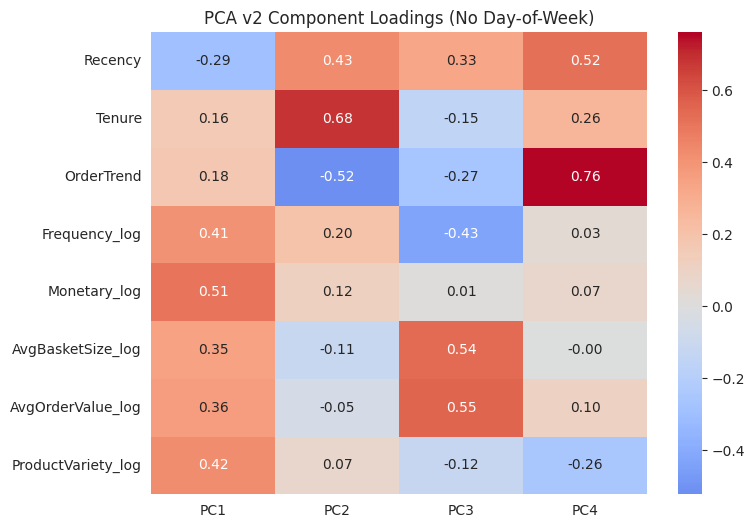

In [73]:
loadings_v2 = pd.DataFrame(
    pca_v2.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_v2)],
    index=scaled_df_v2.columns
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings_v2, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA v2 Component Loadings (No Day-of-Week)')
plt.show()

In [74]:
# top contributors per component

for pc in loadings_v2.columns:
    top_features = loadings_v2[pc].abs().sort_values(ascending=False).head(4)
    print(f'\n{pc} top contributors:')
    print(loadings_v2.loc[top_features.index, pc])


PC1 top contributors:
Monetary_log          0.508028
ProductVariety_log    0.421795
Frequency_log         0.409830
AvgOrderValue_log     0.362963
Name: PC1, dtype: float64

PC2 top contributors:
Tenure           0.683733
OrderTrend      -0.522165
Recency          0.434094
Frequency_log    0.196250
Name: PC2, dtype: float64

PC3 top contributors:
AvgOrderValue_log    0.554797
AvgBasketSize_log    0.540269
Frequency_log       -0.430464
Recency              0.326994
Name: PC3, dtype: float64

PC4 top contributors:
OrderTrend            0.761436
Recency               0.519093
Tenure                0.262340
ProductVariety_log   -0.256379
Name: PC4, dtype: float64


In [75]:
pca_df_v2.to_csv('pca_features_v2.csv', index=False)
loadings_v2.to_csv('pca_loadings_v2.csv')

PC1 — "Spending Intensity / Customer Value"
Dominant: Monetary_log (0.51), Frequency_log (0.41), ProductVariety_log (0.42), AvgOrderValue_log (0.36), AvgBasketSize_log (0.35) — all loading positively together, with Recency mildly negative (-0.29). This is the core value signal: customers who spend more, buy more often, and explore more products score high here. This matches PC1 from original 14-feature run almost exactly, the "real" signal survived removing the Day columns.

PC2 — "Customer Tenure / Lifecycle"
Dominant: Tenure (0.68), Recency (0.43), OrderTrend (-0.52). Long-standing customers whose order trend is declining and who haven't purchased recently. This reads as "Long-tenured but Cooling Off" — a classic lifecycle/churn-risk signal.

PC3 — "Purchase Style: Bulk vs. Frequent"
Dominant: AvgOrderValue_log (0.55), AvgBasketSize_log (0.54) positive, vs. Frequency_log (-0.43) negative. Customers who buy large amounts per order but don't order often, versus customers who order frequently in smaller amounts. This is a genuine behavioral-style axis, distinct from raw value (PC1).

PC4 — "Order Trend / Recency Shift"
Dominant: OrderTrend (0.76), Recency (0.52) — both positive, with everything else fairly weak. This looks like it's isolating customers who are recently accelerating (positive trend, though note the sign relationship with Recency needs a careful read.

## Phase 6 — Clustering: With vs. Without PCA

In [76]:
scaled_df = pd.read_csv('scaled_features.csv')          # original 14-feature scaled set (includes Day_*)
pca_df_v2 = pd.read_csv('pca_features_v2.csv')            # 4-component PCA output (no Day_*)
customer_ids = pd.read_csv('customer_ids.csv')

# For a fair comparison, also build the non-PCA behavioral-only scaled set (no Day_*)
customer_df = pd.read_csv('customer_features_transformed.csv')
skewed_cols = ['Frequency', 'Monetary', 'AvgBasketSize', 'AvgOrderValue', 'ProductVariety']
log_cols = [c + '_log' for c in skewed_cols]
behavioral_cols = ['Recency', 'Tenure', 'OrderTrend'] + log_cols

from sklearn.preprocessing import StandardScaler
scaler_raw = StandardScaler()
scaled_raw = scaler_raw.fit_transform(customer_df[behavioral_cols])
scaled_df_raw = pd.DataFrame(scaled_raw, columns=behavioral_cols)

scaled_df_raw.shape, pca_df_v2.shape

((3920, 8), (3920, 4))

In [77]:
#comparing "raw scaled features" vs. "PCA features" is only a fair test of PCA's value if both start from the same feature set. Since we already established Day_* wasn't adding real signal, we compare the 7 behavioral features raw vs. those same 7 compressed into 4 PCs — not the old 14-feature version. That's the correct apples-to-apples comparison.)

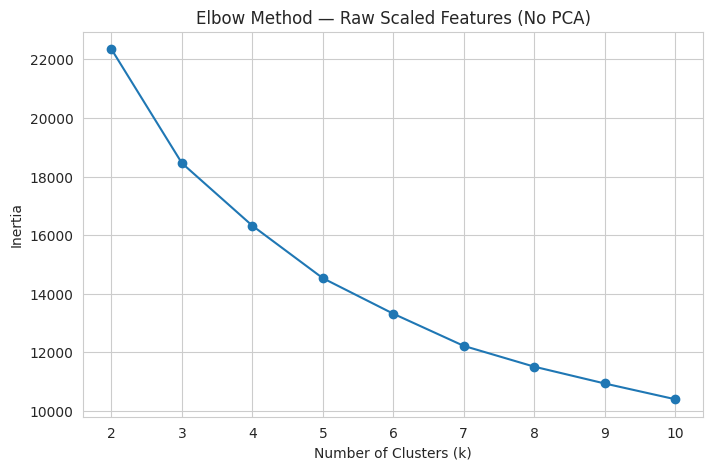

In [78]:
# Elbow method on raw (non-PCA) features

from sklearn.cluster import KMeans

inertia_raw = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df_raw)
    inertia_raw.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_raw, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Raw Scaled Features (No PCA)')
plt.xticks(k_range)
plt.show()

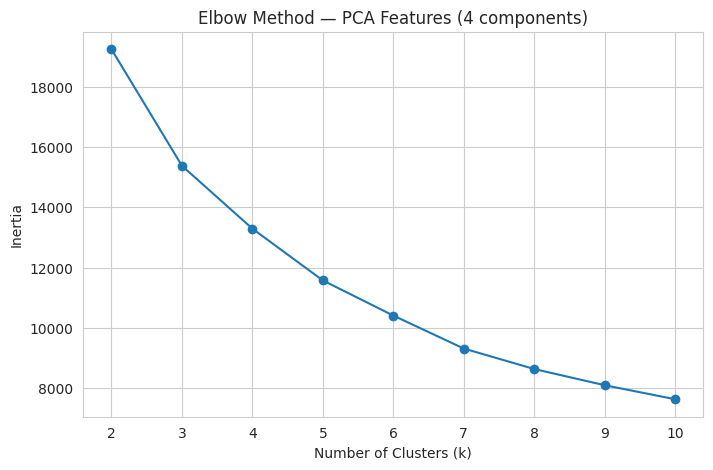

In [79]:
# Elbow method on PCA features

inertia_pca = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df_v2)
    inertia_pca.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_pca, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — PCA Features (4 components)')
plt.xticks(k_range)
plt.show()

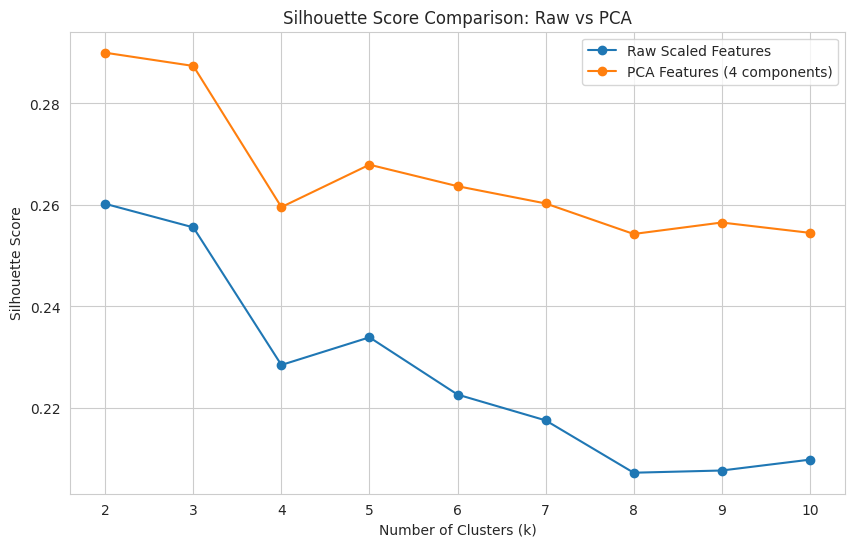

In [80]:
# Silhouette scores across k, both approaches

from sklearn.metrics import silhouette_score

sil_raw = []
sil_pca = []

for k in k_range:
    km_raw = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_df_raw)
    sil_raw.append(silhouette_score(scaled_df_raw, km_raw.labels_))

    km_pca = KMeans(n_clusters=k, random_state=42, n_init=10).fit(pca_df_v2)
    sil_pca.append(silhouette_score(pca_df_v2, km_pca.labels_))

plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_raw, marker='o', label='Raw Scaled Features')
plt.plot(k_range, sil_pca, marker='o', label='PCA Features (4 components)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Comparison: Raw vs PCA')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

In [81]:
# Evidence for PCA, Higher silhoutte score = better-defined clusteers.
# It is found that PCA has improved the clustering quality as shown in the below scores.

comparison = pd.DataFrame({
    'k': list(k_range),
    'Silhouette_Raw': sil_raw,
    'Silhouette_PCA': sil_pca
})
comparison

,k,Silhouette_Raw,Silhouette_PCA
0,2,0.260225,0.290006
1,3,0.255583,0.287399
2,4,0.228465,0.259582
3,5,0.233915,0.267936
4,6,0.222632,0.263701
5,7,0.217547,0.260299
6,8,0.207229,0.254282
7,9,0.207666,0.256541
8,10,0.209804,0.254507


In [82]:
# Fit final KMeans with chosen k on the PCA features

best_k = 3

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_df_v2)

pca_df_v2['Cluster'] = cluster_labels
pca_df_v2['Cluster'].value_counts().sort_index()

Cluster
0    1492
1    1397
2    1031
Name: count, dtype: int64

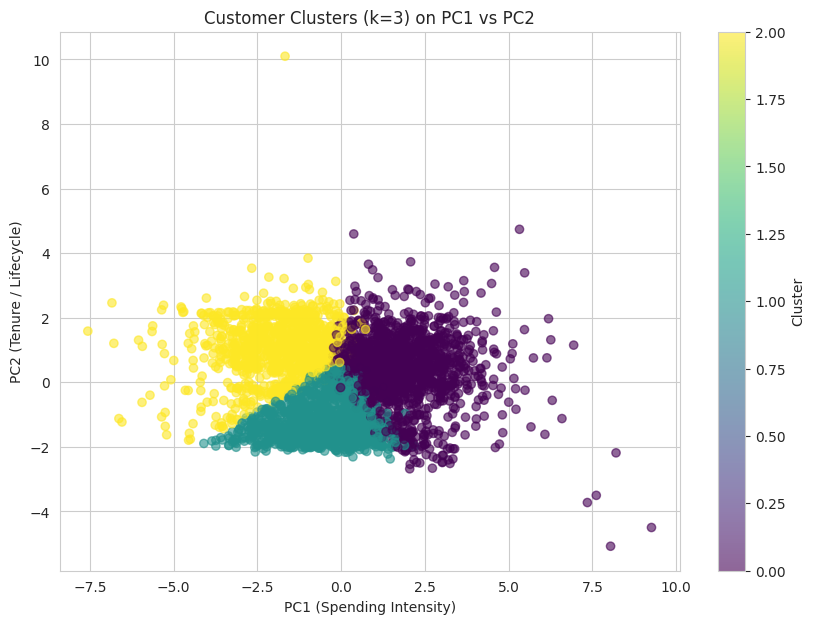

In [83]:
# Visualize clusters on first two PCs

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_df_v2['PC1'], pca_df_v2['PC2'], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PC1 (Spending Intensity)')
plt.ylabel('PC2 (Tenure / Lifecycle)')
plt.title(f'Customer Clusters (k={best_k}) on PC1 vs PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [84]:
customer_ids_reset = customer_ids.reset_index(drop=True)
final_output = pd.concat([customer_ids_reset, pca_df_v2], axis=1)
final_output.to_csv('customer_clusters.csv', index=False)
final_output.head()

,CustomerID,PC1,PC2,PC3,PC4,Cluster
0,12346,5.106341,0.891506,9.686845,2.577385,0
1,12747,1.927037,1.318014,-0.907594,-0.508608,0
2,12748,8.045122,-5.075933,-7.688326,10.023030,0
3,12749,2.794311,-0.678815,0.327281,0.109976,0
4,12820,0.965066,0.070993,-0.749808,0.036241,0


In [85]:
final_output.describe()

,CustomerID,PC1,PC2,PC3,PC4,Cluster
count,3920.000000,3.920000e+03,3.920000e+03,3920.000000,3.920000e+03,3920.000000
mean,15562.059694,2.900174e-17,1.812609e-17,0.000000,-7.250436e-18,0.882398
std,1576.594671,1.892198e+00,1.281134e+00,1.193424,7.512723e-01,0.793696
min,12346.000000,-7.558192e+00,-5.075933e+00,-7.688326,-8.224541e+00,0.000000
25%,14208.750000,-1.303548e+00,-1.235517e+00,-0.773980,-4.257530e-01,0.000000
50%,15569.500000,-1.684968e-02,1.508746e-01,-0.021741,-5.895952e-02,1.000000
75%,16913.250000,1.276160e+00,9.680872e-01,0.781030,3.662310e-01,2.000000
max,18287.000000,9.265673e+00,1.010040e+01,9.686845,1.002303e+01,2.000000


In [86]:
final_output.sort_values('PC1', ascending=False).head(10)

,CustomerID,PC1,PC2,PC3,PC4,Cluster
3783,18102,9.265673,-4.495777,-2.038493,9.003982,0
3314,17450,8.207598,-2.183875,-0.397910,5.505350,0
2,12748,8.045122,-5.075933,-7.688326,10.023030,0
3593,17841,7.618264,-3.500191,-5.583832,7.517646,0
902,14096,7.352680,-3.722852,0.041653,3.985526,0
3356,17511,6.943743,1.152543,1.345701,0.065448,0
2598,16446,6.593697,-1.122243,8.042602,0.832046,0
897,14088,6.303682,-0.557625,1.107651,1.768572,0
1771,15311,6.261143,1.317263,-1.673108,0.421063,0
620,13694,6.193591,1.970934,0.456750,-0.877217,0


In [87]:
customer_df = pd.read_csv('customer_features_transformed.csv')
customer_df[customer_df['CustomerID'].isin([18102, 17450, 12748])]

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log
2,12748,1,209,33053.19,120.990431,158.149234,1768,374,Wednesday,37.0,5.347108,10.405904,4.803943,5.069842,7.478170
3314,17450,8,46,194390.79,1521.152174,4225.886739,124,368,Tuesday,18.0,3.850148,12.177631,7.327881,8.349221,4.828314
3783,18102,1,60,259657.30,1068.733333,4327.621667,150,367,Monday,30.0,4.110874,12.467122,6.975165,8.373004,5.017280


Note: Outlier Handling
Rather than removing high-Monetary/high-Frequency outliers before PCA, we retained them after
confirming log-transformation reduced their leverage. Post-clustering analysis confirmed these
customers were coherently grouped within Cluster 0 (Champions) rather than distorting cluster
boundaries — validating the decision to treat them as a legitimate high-value segment rather
than noise."

## Phase 7 & 8 — Cluster Profiling & Final Summary

In [88]:
# Merge cluster labels back onto original (non-transformed) behavioral values

customer_df = pd.read_csv('customer_features_transformed.csv')
clusters = pd.read_csv('customer_clusters.csv')[['CustomerID', 'Cluster']]

profile_df = customer_df.merge(clusters, on='CustomerID')
profile_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,FavDayOfWeek,OrderTrend,Frequency_log,Monetary_log,AvgBasketSize_log,AvgOrderValue_log,ProductVariety_log,Cluster
0,12346,326,1,77183.60,74215.000000,77183.600000,1,326,Tuesday,-1.0,0.693147,11.253955,11.214735,11.253955,0.693147,0
1,12747,2,11,4196.01,115.909091,381.455455,42,369,Tuesday,-1.0,2.484907,8.342128,4.761397,5.946612,3.761200,0
2,12748,1,209,33053.19,120.990431,158.149234,1768,374,Wednesday,37.0,5.347108,10.405904,4.803943,5.069842,7.478170,0
3,12749,4,5,4090.88,294.200000,818.176000,160,213,Monday,3.0,1.791759,8.316760,5.687653,6.708299,5.081404,0
4,12820,3,4,942.34,180.500000,235.585000,55,327,Monday,2.0,1.609438,6.849427,5.201256,5.466308,4.025352,0


In [89]:
# Cluster Sizes

profile_df['Cluster'].value_counts().sort_index()

Cluster
0    1492
1    1397
2    1031
Name: count, dtype: int64

In [90]:
(profile_df['Cluster'].value_counts(normalize=True) * 100).sort_index()

Cluster
0    38.061224
1    35.637755
2    26.301020
Name: proportion, dtype: float64

In [91]:
# Mean behavioral values per cluster (the actual profile)

profile_cols = ['Recency', 'Frequency', 'Monetary', 'AvgBasketSize',
                 'AvgOrderValue', 'ProductVariety', 'Tenure', 'OrderTrend']

cluster_profile = profile_df.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile

,Recency,Frequency,Monetary,AvgBasketSize,AvgOrderValue,ProductVariety,Tenure,OrderTrend
Cluster,,,,,,,,
0,39.82,8.31,4153.10,353.18,569.23,114.62,301.89,1.18
1,53.36,1.76,529.16,214.34,330.57,33.29,99.30,1.47
2,220.66,1.73,338.86,119.00,217.56,19.92,278.55,-0.87


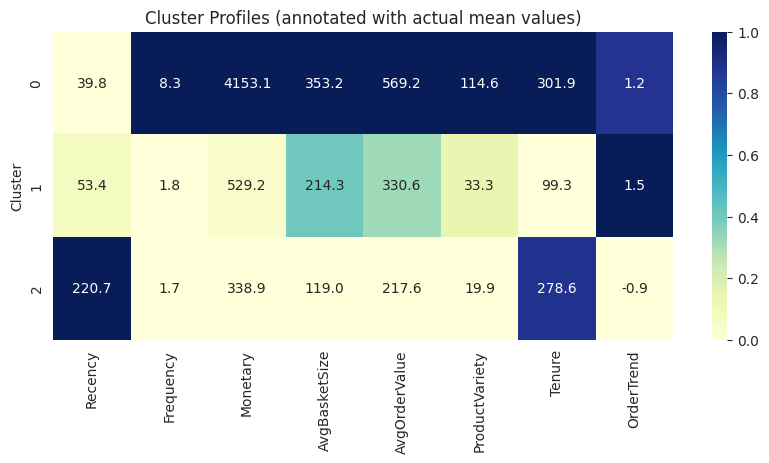

In [92]:
# Visualize the profile as a heatmap

from sklearn.preprocessing import MinMaxScaler

# Normalize just for visualization so all features are on the same 0-1 scale
scaler_viz = MinMaxScaler()
profile_normalized = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(10, 4))
sns.heatmap(profile_normalized, annot=cluster_profile, fmt='.1f', cmap='YlGnBu')
plt.title('Cluster Profiles (annotated with actual mean values)')
plt.show()

In [93]:
profile_df['Cluster'].value_counts().sort_index()

Cluster
0    1492
1    1397
2    1031
Name: count, dtype: int64

Summary & Findings

**PCA Results:** 4 principal components retained 90.11% of variance from 7 behavioral features:
- **PC1 — Spending Intensity:** Monetary, Frequency, ProductVariety, AvgOrderValue
- **PC2 — Tenure/Lifecycle:** Tenure, Recency, OrderTrend
- **PC3 — Purchase Style:** AvgOrderValue/AvgBasketSize vs. Frequency (bulk vs. frequent buying)
- **PC4 — Order Trend/Recency Shift**

**Clustering Results:** PCA-reduced features consistently outperformed raw scaled features on
silhouette score across all tested k values (e.g., k=3: PCA ≈0.287 vs. Raw ≈0.234), while also
reducing dimensionality from 7 to 4 — demonstrating that PCA improved both efficiency and
cluster quality.

**Customer Segments (k=3):**
| Segment | Size | Profile | Recommended Action |
|---|---|---|---|
| Champions | [38.1%] | High spend, frequent, recent, long tenure | Retention: loyalty perks, early access |
| Emerging | [35.6%] | Newer, low volume, positive trend | Growth: onboarding nudges, cross-sell |
| At-Risk | [26.3%] | Long tenure, high recency (dormant), negative trend | Win-back: reactivation campaigns |

**Limitations:** Single-country (UK) scope, one year of data, no seasonality analysis,
K-Means assumes roughly spherical clusters which may not perfectly capture all segment shapes.